<a href="https://colab.research.google.com/github/Kolo-Naukowe-Axion/QC1/blob/main/models/model_simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Environment Setup

This section handles dependency installation and imports. For reproducibility, all package versions should be pinned in a production environment.

### 1.1 Package Installation (Optional)

Set `INSTALL_DEPS = True` if running in a fresh environment. For production use, pin specific versions.

In [1]:
# Optional: Install dependencies if not already present
INSTALL_DEPS = False

if INSTALL_DEPS:
    import sys
    import subprocess

    packages = [
        'numpy',
        'scikit-learn',
        'ucimlrepo',
        'qiskit',
        'qiskit_algorithms',
        'qiskit-machine-learning',
        'iqm-client[qiskit]',
        'torch',
        'matplotlib'
    ]

    for pkg in packages:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

### 1.2 Imports

In [2]:
# Standard library
import random

# Third-party: Scientific computing
import numpy as np
import matplotlib.pyplot as plt

# Third-party: Machine learning
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Third-party: Quantum computing
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.gradients import ParamShiftEstimatorGradient


## 2. Reproducibility and Random Seed Control

In [3]:
def set_random_seed(seed: int = 42) -> None:
    """
    Set random seeds for reproducibility across numpy, PyTorch, and Python's random module.

    Parameters
    ----------
    seed : int
        Random seed value (default: 42)
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# Set global seed
RANDOM_SEED = 42
set_random_seed(RANDOM_SEED)

## 3. Data Preparation

Synthetic regression dataset: $y = \sin(2\pi x) + \epsilon$, with $x \in [0, 1]$ and $\epsilon \sim \mathcal{N}(0, \sigma^2)$.

The single input $x$ is encoded on **all four qubits** using **data re-uploading**: qubit $k$ receives $\mathrm{RY}(k \cdot x)$ for $k = 1, 2, 3, 4$. Multiplying $x$ by increasing integers injects higher Fourier frequencies into the quantum state, giving the ansatz the spectral richness it needs to approximate $\sin(2\pi x)$. Targets $y \in [-1, 1]$ match the Pauli-Z expectation output range.


In [4]:
def prepare_data(
    n_samples: int = 200,
    noise_std: float = 0.15,
    test_size: float = 0.2,
    random_state: int = 42,
    n_qubits: int = 4,
):
    """
    Generate synthetic regression data: y = sin(2*pi*x) + epsilon.

    Data re-uploading: qubit k receives x scaled by (k+1), i.e. x, 2x, 3x, 4x.
    This injects Fourier frequencies 1..n_qubits into the quantum state, giving
    the circuit enough spectral richness to represent sin(2*pi*x).

    Returns
    -------
    X : (n, n_qubits) array -- one column per qubit, each a scaled version of x
    y : (n,) array -- noisy sin targets in [-1, 1]
    """
    rng = np.random.default_rng(random_state)
    x = rng.uniform(0.0, 1.0, size=(n_samples, 1))
    y = np.sin(2 * np.pi * x.ravel()) + rng.normal(0.0, noise_std, size=n_samples)

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        x, y, test_size=test_size, random_state=random_state
    )

    scaler = MinMaxScaler(feature_range=(-np.pi / 4, np.pi / 4))
    x_train_scaled = scaler.fit_transform(X_train_raw)  # (n_train, 1)
    x_test_scaled  = scaler.transform(X_test_raw)       # (n_test,  1)

    # Data re-uploading: qubit k gets x * (k+1) for k in 0..n_qubits-1
    # This encodes frequencies 1x, 2x, 3x, 4x on the four qubits
    multipliers = np.arange(1, n_qubits + 1, dtype=np.float64)  # [1, 2, 3, 4]
    X_train_scaled = x_train_scaled * multipliers   # broadcast: (n_train, n_qubits)
    X_test_scaled  = x_test_scaled  * multipliers   # broadcast: (n_test,  n_qubits)

    print(f'Dataset generated: {len(X_train_scaled)} train, {len(X_test_scaled)} test samples')
    print(f'Re-uploading frequencies: {multipliers.tolist()}')
    print(f'Noise std: {noise_std}, target range (train): [{y_train.min():.3f}, {y_train.max():.3f}]')

    return X_train_scaled, X_test_scaled, y_train, y_test


## 4. Quantum Circuit Architecture

The quantum model consists of two components:
1. **Feature map** (angle encoding): Encodes classical data into quantum states
2. **Ansatz** (trainable circuit): Parametrized quantum circuit with learnable weights

### 4.1 Parametrized Ansatz

Ansatz with alternating rotation and entanglement layers. The circuit uses a ring topology for entanglement, alternating between forward (CRX) and reverse (CRY) connections.

In [5]:
def ansatz(n_qubits, depth):
    """
    Construct a hardware-efficient ansatz with alternating rotation and entanglement layers.

    Architecture
    ------------
    The ansatz consists of (depth // 2) macro-layers, where each macro-layer contains:
    - **Layer 1**: RY rotations + CRX entanglement (forward ring: i → i+1)
    - **Layer 2**: RX rotations + CRY entanglement (reverse ring: i → i-1)

    Parameters
    ----------
    n_qubits : int
        Number of qubits in the circuit
    depth : int
        Number of layers (must be even). Total macro-layers = depth // 2

    Returns
    -------
    QuantumCircuit
        Parametrized quantum circuit with learnable parameters θ

    Notes
    -----
    - Total trainable parameters: 2 × n_qubits × depth
    - Each macro-layer has 4 × n_qubits parameters:
        * n_qubits for RY rotations
        * n_qubits for CRX entanglement angles
        * n_qubits for RX rotations
        * n_qubits for CRY entanglement angles
    - Ring topology ensures all-to-all connectivity with minimal gate depth
    - Constraint: depth must be even (enforced by loop structure)
    """

    # Create a vector of learnable parameters.
    # Total parameters = 2 * num_qubits * depth (2 * n_qubits per full loop iteration).
    theta = ParameterVector('θ', 2 * n_qubits * depth)
    qc = QuantumCircuit(n_qubits)

    param_idx = 0

    # The loop iterates (depth // 2) times.
    for j in range(depth // 2):

        # -------- Layer 1 --------

        # Sub-layer: Independent RY rotations
        for i in range(n_qubits):
            qc.ry(theta[param_idx], i)
            param_idx += 1

        # Sub-layer: Entanglement (CRX) - Ring Topology
        # Connects i -> i+1 (wrapping around to 0 at the end)
        for i in range(n_qubits):
            control = i
            target = (i + 1) % n_qubits
            qc.crx(theta[param_idx], control, target)
            param_idx += 1


        # -------- Layer 2 --------

        # Sub-layer: Independent RX rotations
        for i in range(n_qubits):
            qc.rx(theta[param_idx], i)
            param_idx += 1

        # Sub-layer: Entanglement (CRY) - Reverse Ring Topology
        # Connects i -> i-1 (wrapping around to N-1)
        for i in range(n_qubits):
            control = i
            target = (i - 1) % n_qubits
            qc.cry(theta[param_idx], control, target)
            param_idx += 1

    return qc

### 4.2 Hybrid Variational Quantum Circuit

The `HybridModel` class implements a VQC by integrating the quantum circuit with PyTorch's autograd system via Qiskit's `TorchConnector`. This enables gradient-based optimization of quantum parameters using classical optimizers.

In [6]:
class HybridModel(nn.Module):
    """
    Hybrid Variational Quantum Circuit (VQC) for binary classification.

    The model combines:
    1. Angle encoding feature map (classical data → quantum state)
    2. Parametrized ansatz (trainable quantum circuit)
    3. Observable measurement (quantum state → classical expectation value)
    4. PyTorch integration via TorchConnector (enables backpropagation)

    Parameters
    ----------
    ansatz_circuit : QuantumCircuit
        Parametrized quantum circuit with trainable weights
    num_qubits : int
        Number of qubits (must match feature dimension)

    Attributes
    ----------
    qnn : EstimatorQNN
        Qiskit's EstimatorQNN that computes expectation values
    quantum_layer : TorchConnector
        PyTorch-compatible wrapper enabling gradient computation

    Notes
    -----
    - **Feature encoding**: RY(x_i) on qubit i encodes feature x_i
    - **Observable**: Pauli-Z on qubit 0, measuring spin in computational basis
    - **Output range**: [-1, +1] (expectation value of Z operator)
    - **Gradient method**: Parameter shift rule for quantum gradients
    - **Simulator**: StatevectorEstimator (change for real quantum hardware)
    """

    def __init__(self, ansatz_circuit, num_qubits):
        super().__init__()

        # Create angle encoding feature map
        self.feature_map = self._create_angle_encoding(num_qubits)

        # Compose full quantum circuit: feature_map → ansatz
        self.qc = QuantumCircuit(num_qubits)
        self.qc.compose(self.feature_map, qubits=range(num_qubits), inplace=True)
        self.qc.compose(ansatz_circuit, inplace=True)

        # Separate input parameters (from feature map) and weight parameters (from ansatz)
        # This distinction is crucial for EstimatorQNN to correctly handle data vs. trainable weights
        input_params = list(self.feature_map.parameters)
        weight_params = list(ansatz_circuit.parameters)

        # Define observable: measure Z on qubit 0 (identity on other qubits)
        # Pauli string ordering: rightmost character = qubit 0
        # Example for 5 qubits: "IIIIZ" measures Z on q0, I on q1-q4
        observable = SparsePauliOp.from_list([("I" * (num_qubits - 1) + "Z", 1)])

        # Initialize statevector simulator for noiseless quantum simulation
        # NOTE: Replace with Sampler or real backend for quantum hardware deployment
        estimator = StatevectorEstimator()

        # Parameter-shift gradients (ReverseEstimatorGradient breaks on Qiskit 2.4+ with this ansatz)
        # This is exact (not finite-difference) and works on hardware
        gradient = ParamShiftEstimatorGradient(estimator)

        # Create variational quantum circuit using EstimatorQNN
        # EstimatorQNN computes <ψ|O|ψ> where |ψ> = ansatz(weights)|feature_map(x)>
        self.qnn = EstimatorQNN(
            circuit=self.qc,
            observables=observable,
            input_params=input_params,
            weight_params=weight_params,
            estimator=estimator,
            gradient=gradient
        )

        # Wrap the VQC as a PyTorch module
        # TorchConnector bridges Qiskit and PyTorch autograd systems,
        # allowing standard PyTorch optimizers (SGD, Adam, etc.) to train quantum parameters
        self.quantum_layer = TorchConnector(self.qnn)

    def _create_angle_encoding(self, num_qubits: int) -> QuantumCircuit:
        """
        Create angle encoding feature map: |0⟩ → RY(x₀) ⊗ RY(x₁) ⊗ ... ⊗ RY(xₙ) |0⟩

        Each classical feature x_i ∈ [0, π] is encoded as a rotation angle on qubit i.
        This maps the feature vector to the amplitude of the quantum state.

        Parameters
        ----------
        num_qubits : int
            Number of qubits (and features)

        Returns
        -------
        QuantumCircuit
            Feature map circuit with n_qubits input parameters
        """
        qc_data = QuantumCircuit(num_qubits)
        input_params = ParameterVector('x', num_qubits)
        for i in range(num_qubits):
            qc_data.ry(input_params[i], i)
        return qc_data

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through the hybrid variational quantum circuit.

        Parameters
        ----------
        x : torch.Tensor
            Input features, shape (batch_size, num_qubits)

        Returns
        -------
        torch.Tensor
            Expectation values, shape (batch_size, 1), range [-1, +1]
        """
        return self.quantum_layer(x)

## 5. Training Configuration and Data Loading

In [ ]:
# Hyperparameters
EPOCHS = 30
BATCH_SIZE = 16
LEARNING_RATE = 0.01
NUM_QUBITS = 4  # data re-uploading: qubits encode x, 2x, 3x, 4x (model can approximate up to sin(1 * 2 * 3 * 4 = 10x))
ANSATZ_DEPTHS = [2, 4, 6]
N_SAMPLES = 50
NOISE_STD = 0.10

# Load and prepare data
X_train, X_test, y_train, y_test = prepare_data(
    n_samples=N_SAMPLES,
    noise_std=NOISE_STD,
    test_size=0.2,
    random_state=RANDOM_SEED,
    n_qubits=NUM_QUBITS,
)

X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)


Dataset generated: 160 train, 40 test samples
Re-uploading frequencies: [1.0, 2.0, 3.0, 4.0]
Noise std: 0.1, target range (train): [-1.160, 1.086]


In [8]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)


## 6. Model Training

We train the hybrid VQC using Mean Squared Error (MSE) loss and the Adam optimizer. The training loop evaluates both training and test performance at each epoch.

In [9]:
def train_epoch(model, train_loader, optimizer, loss_fn):
    model.train()
    epoch_loss = 0.0
    num_batches = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = loss_fn(output, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    return epoch_loss / num_batches


def evaluate(model, X_tensor, y_tensor, loss_fn):
    model.eval()
    with torch.no_grad():
        outputs = model(X_tensor)
        loss = loss_fn(outputs, y_tensor).item()
        y_true = y_tensor.cpu().numpy().ravel()
        y_pred = outputs.cpu().numpy().ravel()
        mse = mean_squared_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
    return {'loss': loss, 'mse': mse, 'r2': r2}


loss_function = nn.MSELoss()
training_results = {}

for current_depth in ANSATZ_DEPTHS:
    set_random_seed(RANDOM_SEED)
    final_ansatz = ansatz(NUM_QUBITS, current_depth)
    model = HybridModel(final_ansatz, NUM_QUBITS)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    train_loss_history = []
    test_loss_history = []
    test_r2_history = []

    print(f'Starting training for {EPOCHS} epochs...')
    print(f'Model: {NUM_QUBITS} qubits, ansatz depth {current_depth}')
    print(f'Task: regression y = sin(2πx) + noise (σ={NOISE_STD})')
    print(
        f'Trainable parameters: '
        f"{sum(p.numel() for p in model.parameters() if p.requires_grad)}"
    )
    print('-' * 60)

    for epoch in range(EPOCHS):
        train_loss = train_epoch(model, train_loader, optimizer, loss_function)
        test_metrics = evaluate(model, X_test_tensor, y_test_tensor, loss_function)

        train_loss_history.append(train_loss)
        test_loss_history.append(test_metrics['loss'])
        test_r2_history.append(test_metrics['r2'])

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(
                f'Epoch {epoch + 1:3d}/{EPOCHS} | '
                f'Train Loss: {train_loss:.4f} | '
                f'Test Loss: {test_metrics["loss"]:.4f} | '
                f'Test R²: {test_metrics["r2"]:.4f}'
            )

    final_metrics = evaluate(model, X_test_tensor, y_test_tensor, loss_function)
    training_results[current_depth] = {
        'model': model,
        'train_loss_history': train_loss_history,
        'test_loss_history': test_loss_history,
        'test_r2_history': test_r2_history,
        'final_metrics': final_metrics,
    }
    print('-' * 60)
    print(f'Training complete for depth {current_depth}.')
    print()

selected_depth = ANSATZ_DEPTHS[-1]
selected_result = training_results[selected_depth]
model = selected_result['model']
train_loss_history = selected_result['train_loss_history']
test_loss_history = selected_result['test_loss_history']
test_r2_history = selected_result['test_r2_history']

print(f'Using depth {selected_depth} model for downstream evaluation cells.')


Starting training for 30 epochs...
Model: 4 qubits, ansatz depth 6
Task: regression y = sin(2πx) + noise (σ=0.1)
Trainable parameters: 48
------------------------------------------------------------
Epoch   1/30 | Train Loss: 0.1572 | Test Loss: 0.0941 | Test R²: 0.7810
Epoch   5/30 | Train Loss: 0.0430 | Test Loss: 0.0281 | Test R²: 0.9347
Epoch  10/30 | Train Loss: 0.0213 | Test Loss: 0.0155 | Test R²: 0.9638
Epoch  15/30 | Train Loss: 0.0152 | Test Loss: 0.0125 | Test R²: 0.9709
Epoch  20/30 | Train Loss: 0.0129 | Test Loss: 0.0110 | Test R²: 0.9745
Epoch  25/30 | Train Loss: 0.0124 | Test Loss: 0.0094 | Test R²: 0.9780
Epoch  30/30 | Train Loss: 0.0116 | Test Loss: 0.0097 | Test R²: 0.9773
------------------------------------------------------------
Training complete.


In [ ]:
# Cross-depth comparison: test R² over training epochs
fig, ax = plt.subplots(figsize=(10, 5))

for depth, result in training_results.items():
    epochs_range = range(1, len(result['test_r2_history']) + 1)
    ax.plot(
        epochs_range,
        result['test_r2_history'],
        linewidth=2,
        label=f'Depth {depth}',
    )

ax.set_title('Cross-Depth Comparison: Test R²', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Test R²', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Evaluation and Visualization

We evaluate the trained model with regression metrics (MSE, R²) and plot the predicted curve against the true $\sin(2\pi x)$ function.



Final Test Performance:
  MSE:  0.0100
  R²:   0.9767


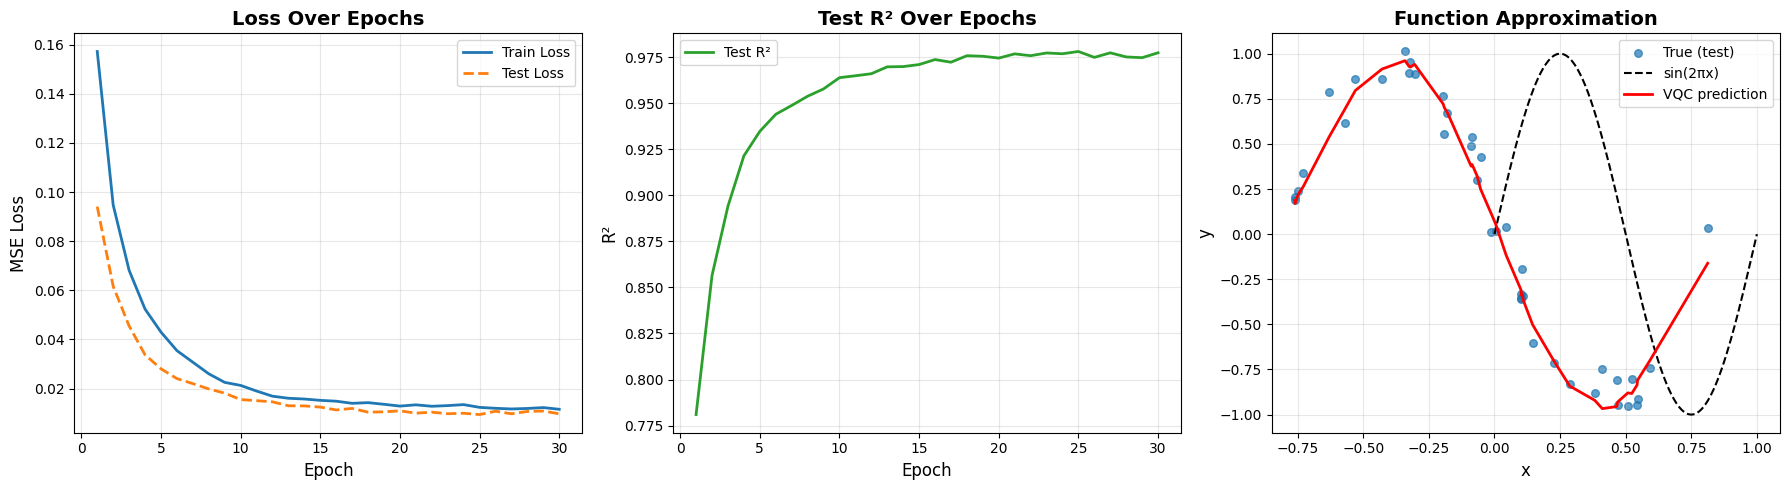

In [10]:
with torch.no_grad():
    y_pred = model(X_test_tensor).cpu().numpy().ravel()

test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)
print(f'\nFinal Test Performance:')
print(f'  MSE:  {test_mse:.4f}')
print(f'  R²:   {test_r2:.4f}')

# Sort by x for a clean curve plot (qubit-0 feature before padding)
x_test = X_test[:, 0]
order = np.argsort(x_test)
x_sorted = x_test[order]
y_true_sorted = y_test[order]
y_pred_sorted = y_pred[order]
x_line = np.linspace(0, 1, 200)
y_line = np.sin(2 * np.pi * x_line)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_range = range(1, len(train_loss_history) + 1)
axes[0].plot(epochs_range, train_loss_history, label='Train Loss', color='#1f77b4', linewidth=2)
axes[0].plot(
    epochs_range,
    test_loss_history,
    label='Test Loss',
    color='#ff7f0e',
    linewidth=2,
    linestyle='--',
)
axes[0].set_title('Loss Over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, test_r2_history, label='Test R²', color='#2ca02c', linewidth=2)
axes[1].set_title('Test R² Over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('R²', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

axes[2].scatter(x_sorted, y_true_sorted, label='True (test)', alpha=0.7, s=30)
axes[2].plot(x_line, y_line, 'k--', linewidth=1.5, label='sin(2πx)')
axes[2].plot(x_sorted, y_pred_sorted, 'r-', linewidth=2, label='VQC prediction')
axes[2].set_title('Function Approximation', fontsize=14, fontweight='bold')
axes[2].set_xlabel('x', fontsize=12)
axes[2].set_ylabel('y', fontsize=12)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Summary and Reproducibility Notes

### Reproducibility

- **Random seed**: Fixed at `RANDOM_SEED = 42`
- **Data generation**: Deterministic with `np.random.default_rng(42)`
- **Feature scaling**: MinMaxScaler fit only on training data

### VQC Architecture Summary

- **Task**: Regression -- predict $y = \sin(2\pi x) + \epsilon$
- **Qubits**: 4 (data re-uploading: qubit $k$ encodes $k \cdot x$ for $k = 1..4$)
- **Ansatz depths**: 2, 4, and 6 layers (`ANSATZ_DEPTHS = [2, 4, 6]`)
- **Trainable parameters**: $2 \times 4 \times \text{depth}$ quantum parameters
- **Feature encoding**: Angle encoding via RY gates with frequency multipliers $[1, 2, 3, 4]$
- **Observable**: Pauli-Z expectation on qubit 0 (output range $[-1, +1]$)
- **Optimizer**: Adam, learning rate 0.01
- **Loss**: Mean Squared Error (MSE)

### Why data re-uploading?

A VQC with a single angle-encoded qubit can only represent functions whose Fourier spectrum contains frequencies up to the number of times $x$ appears in the circuit. With one qubit encoding $x$ once, the maximum accessible frequency is 1 -- barely enough to sketch $\sin(2\pi x)$ and insufficient to fit it accurately. Re-uploading $x$ on $n$ qubits with multipliers $1, 2, \ldots, n$ extends the accessible spectrum to frequencies $\{1, 2, \ldots, n\}$, giving the ansatz the expressive power it needs. This is the standard quantum analogue of adding Fourier basis features.

### References

- Qiskit Machine Learning: https://qiskit.org/ecosystem/machine-learning/
- Perez-Salinas et al., Data re-uploading for a universal quantum classifier, Quantum 4, 226 (2020)
- Schuld et al., Effect of data encoding on the expressive power of variational quantum-machine-learning models, Phys. Rev. A 103, 032430 (2021)
- Cerezo et al., Variational Quantum Algorithms, Nature Reviews Physics 3, 625-644 (2021)
